In [61]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [34]:
from google.colab import files
uploaded = files.upload()

Saving train_1.csv to train_1 (1).csv


In [36]:
df = pd.read_csv('train_1.csv')


In [37]:
y = df['label'].values
X = df.drop('label', axis=1).values

In [38]:
X = X / 255.0  # Normalize pixels to 0-1 range
X = X.reshape(-1, 28, 28, 1) #fold back into 28x28 square with 1 color channel

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [40]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),


    layers.Dense(128, activation='relu'),


    layers.Dropout(0.2),


    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [42]:
print("Training started...")
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

Training started...
Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - accuracy: 0.9188 - loss: 0.2603 - val_accuracy: 0.9750 - val_loss: 0.0835
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.9782 - loss: 0.0692 - val_accuracy: 0.9786 - val_loss: 0.0704
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.9847 - loss: 0.0479 - val_accuracy: 0.9862 - val_loss: 0.0411
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.9883 - loss: 0.0373 - val_accuracy: 0.9848 - val_loss: 0.0444
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - accuracy: 0.9905 - loss: 0.0289 - val_accuracy: 0.9900 - val_loss: 0.0336
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.9919 - loss: 0.0254 - val_accuracy: 0.9895 - val_loss: 0.0330
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9938 - loss: 0.0184 - val_accuracy: 0.9879 - val_loss: 0.0416
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.99


 Testing on a Random Image


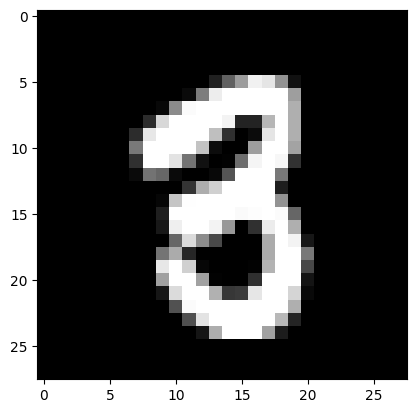

In [56]:
print("\n Testing on a Random Image")
sample_idx = np.random.randint(1, len(X_test))
plt.imshow(X_test[sample_idx].reshape(28,28), cmap='gray')
plt.show()

In [57]:
pred_probs = model.predict(X_test[sample_idx:sample_idx+1])
predicted_digit = np.argmax(pred_probs)
actual_digit = y_test[sample_idx]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [58]:
print(f"Model Prediction: {predicted_digit}")
print(f"Actual Label: {actual_digit}")

Model Prediction: 3
Actual Label: 3


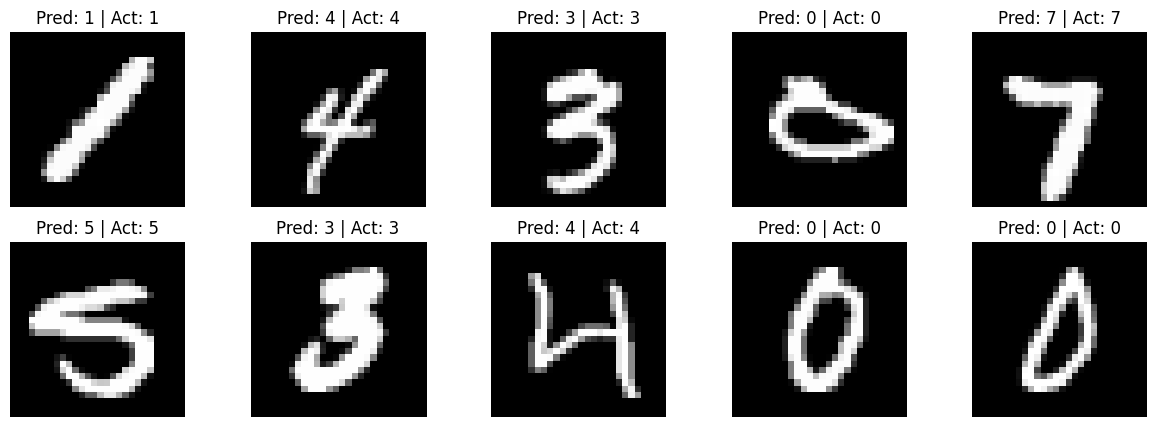

In [59]:
plt.figure(figsize=(15, 5))
for i in range(10):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx].reshape(28, 28)

    # Predict
    pred = model.predict(X_test[idx:idx+1], verbose=0)
    digit = np.argmax(pred)

    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {digit} | Act: {y_test[idx]}")
    plt.axis('off')
plt.show()